monthly_close shape: (132, 502)
monthly_ret shape: (132, 502)
monthly_close index head: DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31'],
              dtype='datetime64[ns]', name='Date', freq='ME')
monthly_ret index head: DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31'],
              dtype='datetime64[ns]', name='Date', freq='ME')

Number of formation portfolios: 125
First few formation dates:
[Timestamp('2015-07-31 00:00:00'), Timestamp('2015-08-31 00:00:00'), Timestamp('2015-09-30 00:00:00'), Timestamp('2015-10-31 00:00:00'), Timestamp('2015-11-30 00:00:00')]

Event-time table head:


,winner_monthly_ret,loser_monthly_ret,ls_monthly_ret,winner_monthly_t,loser_monthly_t,ls_monthly_t,winner_cum_ret,loser_cum_ret,ls_cum_ret,winner_cum_t,loser_cum_t,ls_cum_t,n_portfolios,ls_cum_from_mean_monthly
t,,,,,,,,,,,,,,
1,0.0211,0.0166,0.0045,4.1245,2.6031,0.9284,0.0211,0.0166,0.0045,4.1245,2.6031,0.9284,125,0.0045
2,0.0206,0.0173,0.0033,4.0721,2.9327,0.7407,0.0416,0.0334,0.0074,6.0307,4.1109,1.1836,124,0.0078
3,0.0204,0.0178,0.0026,3.9978,2.8123,0.5500,0.0623,0.0503,0.0096,7.6002,5.3974,1.3186,123,0.0105
4,0.0201,0.0181,0.0020,3.6333,2.8507,0.4121,0.0822,0.0681,0.0098,8.5337,6.4508,1.2560,122,0.0125
5,0.0201,0.0160,0.0042,3.6726,2.5202,0.9057,0.1020,0.0843,0.0123,9.8131,7.1514,1.4726,121,0.0167
6,0.0214,0.0201,0.0013,4.1083,3.1017,0.2814,0.1246,0.1047,0.0127,10.9400,8.0761,1.3650,120,0.0180
7,0.0210,0.0208,0.0003,4.1621,3.2333,0.0576,0.1470,0.1266,0.0138,11.9319,8.5095,1.2347,119,0.0183
8,0.0196,0.0210,-0.0014,3.8403,3.3535,-0.2890,0.1682,0.1495,0.0138,12.6442,8.6228,1.0678,118,0.0169
9,0.0196,0.0184,0.0012,3.8089,3.1529,0.2822,0.1913,0.1688,0.0170,12.5770,8.8770,1.1956,117,0.0181



Event-time table (selected months):


,winner_monthly_ret,loser_monthly_ret,ls_monthly_ret,winner_monthly_t,loser_monthly_t,ls_monthly_t,winner_cum_ret,loser_cum_ret,ls_cum_ret,winner_cum_t,loser_cum_t,ls_cum_t,n_portfolios,ls_cum_from_mean_monthly
t,,,,,,,,,,,,,,
1,0.0211,0.0166,0.0045,4.1245,2.6031,0.9284,0.0211,0.0166,0.0045,4.1245,2.6031,0.9284,125,0.0045
2,0.0206,0.0173,0.0033,4.0721,2.9327,0.7407,0.0416,0.0334,0.0074,6.0307,4.1109,1.1836,124,0.0078
3,0.0204,0.0178,0.0026,3.9978,2.8123,0.5500,0.0623,0.0503,0.0096,7.6002,5.3974,1.3186,123,0.0105
6,0.0214,0.0201,0.0013,4.1083,3.1017,0.2814,0.1246,0.1047,0.0127,10.9400,8.0761,1.3650,120,0.0180
12,0.0211,0.0177,0.0033,3.7261,2.9905,0.7365,0.2614,0.2349,0.0183,13.0448,9.8100,1.0755,114,0.0195
24,0.0127,0.0181,-0.0054,2.0065,3.1247,-1.3037,0.4838,0.5206,-0.0211,15.5667,14.1963,-0.7719,102,0.0001
36,0.0172,0.0158,0.0014,2.4423,2.3429,0.3144,0.6816,0.7852,-0.0565,24.1952,17.5898,-1.9761,90,0.0163



Diagnostics:
Month 1 LS monthly return  : 0.0045
Month 12 LS monthly return : 0.0033
Month 36 LS monthly return : 0.0014
Month 12 LS cumulative ret  : 0.0183
Month 24 LS cumulative ret  : -0.0211
Month 36 LS cumulative ret  : -0.0565
Peak cumulative LS return at t = 14, value = 0.0223


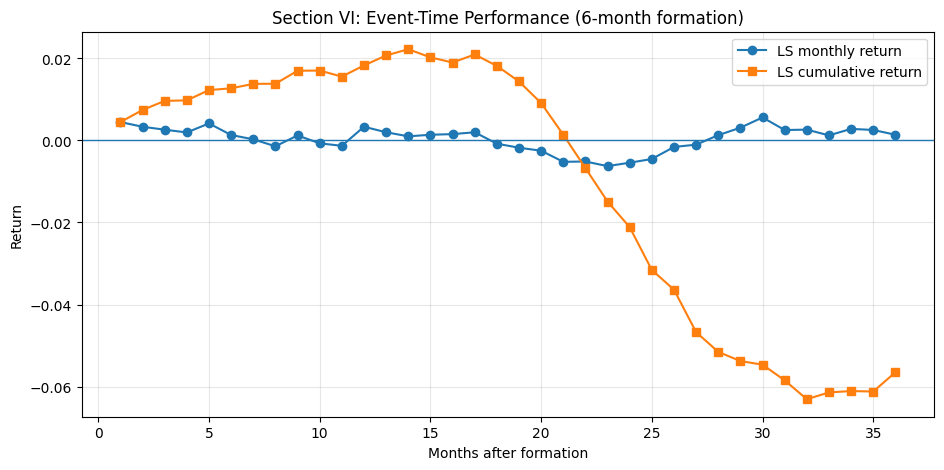

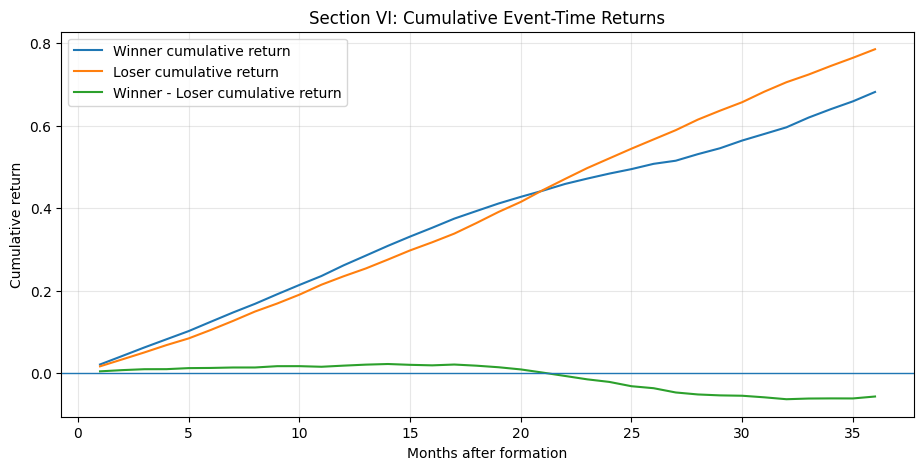


Summary:
Average event-time monthly LS return (across t): 0.0005
Number of event months with data: 36
Number of formation portfolios used: 125

Saved outputs to ../results/


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Section VI (strict event-time implementation)
# 6-month formation window, 36-month event horizon
# No overlapping calendar-time trading rule here.
# ============================================================

# ----------------------------
# 1) Load data
# ----------------------------
prices = pd.read_parquet("../data/sp500_prices.parquet")

daily_close = prices["Close"].copy().sort_index()
daily_close = daily_close.dropna(axis=1, how="all")

monthly_close = daily_close.resample("ME").last()
monthly_close = monthly_close.dropna(axis=1, how="all")

monthly_ret = monthly_close.pct_change(fill_method=None)

print("monthly_close shape:", monthly_close.shape)
print("monthly_ret shape:", monthly_ret.shape)
print("monthly_close index head:", monthly_close.index[:5])
print("monthly_ret index head:", monthly_ret.index[:5])


# ----------------------------
# 2) Helpers
# ----------------------------
def compute_formation_signal(monthly_close: pd.DataFrame, J: int = 6) -> pd.DataFrame:
    """
    Past J-month cumulative return used for ranking.
    signal[t] = P_t / P_{t-J} - 1
    """
    return monthly_close.pct_change(periods=J, fill_method=None)


def assign_deciles(signal_row: pd.Series, n_deciles: int = 10) -> pd.Series:
    """
    1 = losers decile
    10 = winners decile
    """
    x = signal_row.dropna()
    if len(x) < n_deciles:
        return pd.Series(dtype="int64")

    # Use rank-first to avoid qcut issues with ties
    ranks = x.rank(method="first")
    labels = pd.qcut(ranks, n_deciles, labels=False) + 1
    return pd.Series(labels.astype(int), index=x.index)


def mean_tstat(x: pd.Series) -> tuple[float, float, int]:
    """
    Cross-sectional mean and t-stat across formation portfolios.
    """
    x = pd.Series(x).dropna()
    n = len(x)
    if n <= 1:
        return np.nan, np.nan, n
    mu = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    t = mu / se if se > 0 else np.nan
    return mu, t, n


def nw_tstat_on_series(x: pd.Series, maxlags: int = 5) -> tuple[float, float]:
    """
    Newey-West t-stat for the mean of a time series.
    """
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan, np.nan
    X = np.ones((len(x), 1))
    model = sm.OLS(x.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return float(model.params[0]), float(model.tvalues[0])


# ----------------------------
# 3) Build formation portfolios
# ----------------------------
def build_formation_portfolios(
    monthly_close: pd.DataFrame,
    J: int = 6,
    n_deciles: int = 10,
) -> list[dict]:
    """
    For each formation month:
    - rank stocks by past J-month cumulative return
    - store winner/loser constituents
    - start tracking from next month
    """
    signal = compute_formation_signal(monthly_close, J=J)
    dates = monthly_close.index

    formation_portfolios = []

    for formation_pos, dt in enumerate(dates):
        if dt not in signal.index:
            continue

        row = signal.loc[dt]
        deciles = assign_deciles(row, n_deciles=n_deciles)
        if deciles.empty:
            continue

        winners = deciles[deciles == n_deciles].index.tolist()
        losers = deciles[deciles == 1].index.tolist()

        # Track returns starting from next month
        start_pos = formation_pos + 1
        if start_pos >= len(dates):
            continue

        formation_portfolios.append(
            {
                "formation_date": dt,
                "start_pos": start_pos,
                "winners": winners,
                "losers": losers,
            }
        )

    return formation_portfolios


# ----------------------------
# 4) Compute event-time matrices
# ----------------------------
def build_event_time_matrices(
    monthly_ret: pd.DataFrame,
    formation_portfolios: list[dict],
    horizon: int = 36,
) -> dict:
    """
    For each formation portfolio, compute monthly event-time returns
    for winner, loser, and long-short over the next `horizon` months.

    Returns a dict with matrices:
        winner_mat, loser_mat, ls_mat, winner_cum_mat, loser_cum_mat, ls_cum_mat
    Shape: (n_formations, horizon)
    """
    dates = monthly_ret.index
    n_forms = len(formation_portfolios)

    winner_mat = np.full((n_forms, horizon), np.nan, dtype=float)
    loser_mat = np.full((n_forms, horizon), np.nan, dtype=float)
    ls_mat = np.full((n_forms, horizon), np.nan, dtype=float)

    winner_cum_mat = np.full((n_forms, horizon), np.nan, dtype=float)
    loser_cum_mat = np.full((n_forms, horizon), np.nan, dtype=float)
    ls_cum_mat = np.full((n_forms, horizon), np.nan, dtype=float)

    for i, fp in enumerate(formation_portfolios):
        cum_w = 1.0
        cum_l = 1.0
        cum_ls = 1.0

        for t in range(1, horizon + 1):
            pos = fp["start_pos"] + (t - 1)
            if pos >= len(dates):
                break

            dt = dates[pos]
            r = monthly_ret.loc[dt]

            w = fp["winners"]
            l = fp["losers"]

            wret = r[w].dropna().mean() if len(w) > 0 else np.nan
            lret = r[l].dropna().mean() if len(l) > 0 else np.nan

            if pd.isna(wret) or pd.isna(lret):
                continue

            lsret = wret - lret

            winner_mat[i, t - 1] = wret
            loser_mat[i, t - 1] = lret
            ls_mat[i, t - 1] = lsret

            cum_w *= (1 + wret)
            cum_l *= (1 + lret)
            cum_ls *= (1 + lsret)

            winner_cum_mat[i, t - 1] = cum_w - 1
            loser_cum_mat[i, t - 1] = cum_l - 1
            ls_cum_mat[i, t - 1] = cum_ls - 1

    return {
        "winner_mat": winner_mat,
        "loser_mat": loser_mat,
        "ls_mat": ls_mat,
        "winner_cum_mat": winner_cum_mat,
        "loser_cum_mat": loser_cum_mat,
        "ls_cum_mat": ls_cum_mat,
    }


# ----------------------------
# 5) Summarize event-time results
# ----------------------------
def summarize_event_matrix(mat: np.ndarray, horizon: int = 36) -> pd.DataFrame:
    """
    For each event month t:
    - mean across formation portfolios
    - t-stat across formation portfolios
    - number of contributing portfolios
    """
    rows = []
    for t in range(horizon):
        x = pd.Series(mat[:, t]).dropna()
        mu, tstat, n = mean_tstat(x)
        rows.append(
            {
                "t": t + 1,
                "mean": mu,
                "tstat": tstat,
                "n_portfolios": n,
            }
        )
    return pd.DataFrame(rows).set_index("t")


# ----------------------------
# 6) Run the strict Section VI event study
# ----------------------------
J = 6
H = 36

formation_portfolios = build_formation_portfolios(
    monthly_close=monthly_close,
    J=J,
    n_deciles=10,
)

print(f"\nNumber of formation portfolios: {len(formation_portfolios)}")
print("First few formation dates:")
print([fp["formation_date"] for fp in formation_portfolios[:5]])

event_mats = build_event_time_matrices(
    monthly_ret=monthly_ret,
    formation_portfolios=formation_portfolios,
    horizon=H,
)

# Summaries
winner_evt = summarize_event_matrix(event_mats["winner_mat"], horizon=H)
loser_evt = summarize_event_matrix(event_mats["loser_mat"], horizon=H)
ls_evt = summarize_event_matrix(event_mats["ls_mat"], horizon=H)

winner_cum_evt = summarize_event_matrix(event_mats["winner_cum_mat"], horizon=H)
loser_cum_evt = summarize_event_matrix(event_mats["loser_cum_mat"], horizon=H)
ls_cum_evt = summarize_event_matrix(event_mats["ls_cum_mat"], horizon=H)

# Compact event table
event_df = pd.DataFrame(index=range(1, H + 1))
event_df.index.name = "t"

event_df["winner_monthly_ret"] = winner_evt["mean"]
event_df["loser_monthly_ret"] = loser_evt["mean"]
event_df["ls_monthly_ret"] = ls_evt["mean"]

event_df["winner_monthly_t"] = winner_evt["tstat"]
event_df["loser_monthly_t"] = loser_evt["tstat"]
event_df["ls_monthly_t"] = ls_evt["tstat"]

event_df["winner_cum_ret"] = winner_cum_evt["mean"]
event_df["loser_cum_ret"] = loser_cum_evt["mean"]
event_df["ls_cum_ret"] = ls_cum_evt["mean"]

event_df["winner_cum_t"] = winner_cum_evt["tstat"]
event_df["loser_cum_t"] = loser_cum_evt["tstat"]
event_df["ls_cum_t"] = ls_cum_evt["tstat"]

event_df["n_portfolios"] = ls_evt["n_portfolios"]

# Also add cumulative compounding of the mean monthly LS return curve
event_df["ls_cum_from_mean_monthly"] = (1 + event_df["ls_monthly_ret"]).cumprod() - 1

print("\nEvent-time table head:")
display(event_df.head(12).round(4))

print("\nEvent-time table (selected months):")
display(event_df.loc[[1, 2, 3, 6, 12, 24, 36]].round(4))


# ----------------------------
# 7) Paper-style diagnostics
# ----------------------------
print("\nDiagnostics:")
print(f"Month 1 LS monthly return  : {event_df.loc[1, 'ls_monthly_ret']:.4f}")
print(f"Month 12 LS monthly return : {event_df.loc[12, 'ls_monthly_ret']:.4f}")
print(f"Month 36 LS monthly return : {event_df.loc[36, 'ls_monthly_ret']:.4f}")

print(f"Month 12 LS cumulative ret  : {event_df.loc[12, 'ls_cum_ret']:.4f}")
print(f"Month 24 LS cumulative ret  : {event_df.loc[24, 'ls_cum_ret']:.4f}")
print(f"Month 36 LS cumulative ret  : {event_df.loc[36, 'ls_cum_ret']:.4f}")

peak_t = event_df["ls_cum_ret"].idxmax()
peak_val = event_df["ls_cum_ret"].max()
print(f"Peak cumulative LS return at t = {peak_t}, value = {peak_val:.4f}")


# ----------------------------
# 8) Plots
# ----------------------------
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(event_df.index, event_df["ls_monthly_ret"], marker="o", label="LS monthly return")
ax.plot(event_df.index, event_df["ls_cum_ret"], marker="s", label="LS cumulative return")
ax.axhline(0, linewidth=1)
ax.set_title("Section VI: Event-Time Performance (6-month formation)")
ax.set_xlabel("Months after formation")
ax.set_ylabel("Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(event_df.index, event_df["winner_cum_ret"], label="Winner cumulative return")
ax.plot(event_df.index, event_df["loser_cum_ret"], label="Loser cumulative return")
ax.plot(event_df.index, event_df["ls_cum_ret"], label="Winner - Loser cumulative return")
ax.axhline(0, linewidth=1)
ax.set_title("Section VI: Cumulative Event-Time Returns")
ax.set_xlabel("Months after formation")
ax.set_ylabel("Cumulative return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


# ----------------------------
# 9) Optional summary stats
# ----------------------------
ls_mean = event_df["ls_monthly_ret"].mean()
ls_mean_t = event_df["ls_monthly_ret"].dropna().shape[0]
print("\nSummary:")
print(f"Average event-time monthly LS return (across t): {ls_mean:.4f}")
print(f"Number of event months with data: {len(event_df.dropna(subset=['ls_monthly_ret']))}")
print(f"Number of formation portfolios used: {len(formation_portfolios)}")


# ----------------------------
# 10) Save outputs
# ----------------------------
Path("../results").mkdir(exist_ok=True)

event_df.to_csv("../results/section6_strict_event_time.csv")
winner_evt.to_csv("../results/section6_winner_monthly_summary.csv")
loser_evt.to_csv("../results/section6_loser_monthly_summary.csv")
ls_evt.to_csv("../results/section6_ls_monthly_summary.csv")

print("\nSaved outputs to ../results/")